### **Muffin vs. Chihuahua**: How to confuse Machine Learning

In [ ]:
import tensorflow as tf
import random
import os
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# you need the current working directory NB: works both windows and linux
current_working_directory = os.getcwd()
current_working_directory = os.path.dirname(current_working_directory)

# get the directory where I want to download the dataset
path_of_download = os.path.join(*['..', current_working_directory, 'Datasets', 'cookies_vs_chihuahua'])
print(f"[DIR] The directory of the current dataset is {path_of_download}")

[DIR] The directory of the current dataset is /Datasets/cookies_vs_chihuahua


In [ ]:
dataset_path = '/content/drive/MyDrive/Datasets/cookies_vs_chihuahua'

In [ ]:
# here let s do some functions that we can re-use also for other assignment
def load_the_data_and_the_labels(data_set_path: str, target_size: tuple or None = None):
    try:
        dataset, labels, name_of_the_labels = list(), list(), list()
        # let s loop here and we try to discover how many class we have
        for class_number, class_name in enumerate(os.listdir(data_set_path)):
            full_path_the_data = os.path.join(data_set_path, class_name)
            print(f"[WALK] I am walking into {full_path_the_data}")

            # add the list to nam _list
            name_of_the_labels.append(class_name)

            for single_image in os.listdir(f"{full_path_the_data}"):
                full_path_to_image = os.path.join(*[full_path_the_data, single_image])

                # add the class number
                labels.append(class_number)

                if target_size is None:
                    # let s load the image
                    image = tf.keras.utils.load_img(full_path_to_image)
                else:
                    image = tf.keras.utils.load_img(full_path_to_image, target_size=target_size)

                # transform PIL object in image
                image = tf.keras.utils.img_to_array(image)

                # add the image to the ds list
                dataset.append(image)

        return np.array(dataset, dtype='uint8'), np.array(labels, dtype='int'), name_of_the_labels
    except Exception as ex:
        print(f"[EXCEPTION] load the data and the labels throws exceptions {ex}")

In [ ]:
# loading the training set
train_path = os.path.join(dataset_path, 'train')
X, y, class_names = load_the_data_and_the_labels(train_path, target_size=(224, 224, 3))

[WALK] I am walking into /content/drive/MyDrive/Datasets/cookies_vs_chihuahua/train/chihuahua
[WALK] I am walking into /content/drive/MyDrive/Datasets/cookies_vs_chihuahua/train/muffin


In [ ]:
# loading the test set
test_path = os.path.join(dataset_path, 'test')
X_test, y_test, _ = load_the_data_and_the_labels(test_path, target_size=(224, 224, 3))

[WALK] I am walking into /content/drive/MyDrive/Datasets/cookies_vs_chihuahua/test/chihuahua
[WALK] I am walking into /content/drive/MyDrive/Datasets/cookies_vs_chihuahua/test/muffin


Here, I am converting the dataset X to float32 datatype and scaling them from the range 0-255 (this is the grayscale/RGB values of images) to 0-1 which is normalization. Then I am controlling the shapes in case of they are not correctly normalized.

In [ ]:
X = X.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
# for controlling the shapes
print(f"Train set shape: {X.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Class names: {class_names}")

Train set shape: (4733, 224, 224, 3)
Test set shape: (1184, 224, 224, 3)
Class names: ['chihuahua', 'muffin']


Splitting the dataset into training (0.7) and validation (0.3) sets while ensuring class balance in training and validation sets.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Creating a CNN with the following characteristics:
a.	Input layer
b.	Data augmentation, with random flip and random rotation.
c.	Two hidden layers each composed with the following characteristics: 16 conv2d units, max pooling 2d and batch normalization, the second one should have 24 conv2d units max pooling 2d and batch normalization.
d.	After this, add a flatten layer and a dense layer with 8 units
e.	Add the final classifier (a  dense layer) with the correct number of output and activation


In [ ]:
model = keras.Sequential()

# input layer
input_shape = (224, 224, 3)
model.add(layers.Input(shape=input_shape))

# data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
    ]
)
model.add(data_augmentation)

# initial hidden layer
model.add(layers.Conv2D(16, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())

# second hidden layer
model.add(layers.Conv2D(24, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())

# flatten layer
model.add(layers.Flatten())

# dense layer
model.add(layers.Dense(8, activation='relu'))

# final classifier (dense layer)
model.add(layers.Dense(1, activation='sigmoid'))

I used this block to check if my data augmentation works properly. It loads a single image, applies data augmentation to it and visualizes both the original and augmented images using matplotlib.

Found 5917 files belonging to 2 classes.


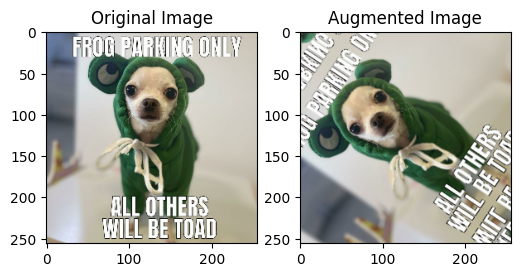

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
)

for images, _ in dataset.take(1):
    sample_image = images[0]
    break

augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image.numpy().astype("uint8"))

plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(augmented_image[0].numpy().astype("uint8"))

plt.show()

### Compiling the model using Adam

here it compiles the neural network using Adam optimizer and binary cross entropy loss. Then, it is printing the model's architecture to check if it is correctly built or not.

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 112, 112, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 24)        │           3,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 24)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 56, 56, 24)          │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 75264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │         602,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 606,217 (2.31 MB)

 Trainable params: 606,137 (2.31 MB)

 Non-trainable params: 80 (320.00 B)

### Training the model with batch size 64 and epochs of 30

In this block, I am training the model for 30 epochs and a batch size of 64.

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=30,
    verbose=1
)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.6707 - loss: 0.9021 - val_accuracy: 0.4887 - val_loss: 0.8394
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7709 - loss: 0.4365 - val_accuracy: 0.4479 - val_loss: 0.9143
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.8444 - loss: 0.3880 - val_accuracy: 0.5451 - val_loss: 1.0320
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8517 - loss: 0.3694 - val_accuracy: 0.5162 - val_loss: 1.3628
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8640 - loss: 0.3405 - val_accuracy: 0.5324 - val_loss: 1.3718
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8782 - loss: 0.3208 - val_accuracy: 0.5380 - val_loss: 1.7531
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8760 - loss: 0.3281 - val_accuracy: 0.5401 - val_loss: 1.3617
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8793 - loss: 0.3061 - val_accuracy: 0.5415 - 

### Evaluating the model and report the accuracy

This block evaluates the trained model on the test dataset and shows the test accuracy.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

37/37 - 0s - 12ms/step - accuracy: 0.7373 - loss: 0.6834

Test accuracy: 0.7373


My model achieved %73.73 accuracy, so it is correctly classifying %73.73 of the test samples. My loss is 0.6834, which needs to be improved (its value needs to get smaller) in order to have better performance.

#### Making prediction with the test set

initially, I am converting predicted probabilities into binary class labels (using 0.5 threshold), then computing the ROC curve metrics fpr (false positive rate), tpr (true positive rate) and thresholds to evaluate the models classification performance across different thresholds.


In [ ]:
y_pred_labels = (y_pred_prob >= 0.5).astype(int)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

### Plotting confusion matrix and ROC curve

In this block, I am computing the confusion matrix using binary predictions.

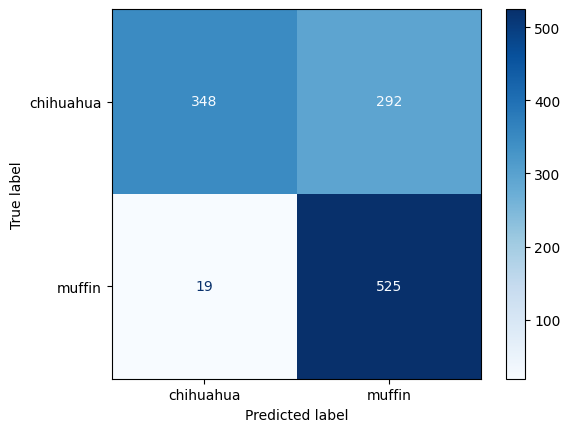

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

I have 348 true negatives, 292 false positives, 19 false negatives, and 525 true positives. So, my model correctly classified 348 negative instances and 525 positive instances, but it misclassified 292 negatives as positives and 19 positives as negatives. This shows high false positive rate.

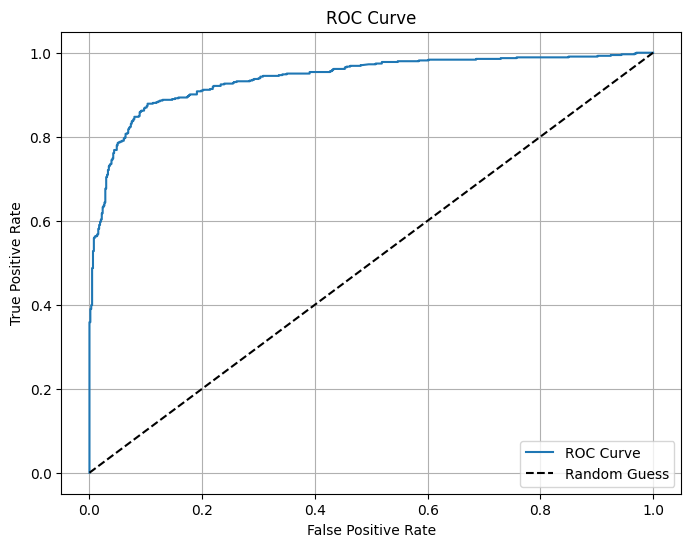

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In this block, I am plotting the ROC curve. I have false positive rate on x-axis and true positive rate on y-axis. The ROC curve shows model performance across all thresholds. And a better model will have a ROC curve closer to top-left corner. So, my curve is approaching the top-left corner which means my model is correctly identifying most of the positive instances.


### Calculating best testhold

In this block, by maximizing the difference between tpr and fpr I am finding optimal threshold.

In [ ]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.94868577


The optimal threshold for my model is 0.94868577. So, any predicted probability above nearly 0.95 will be classified as positive. High threshold means my model is being conservative in predicting positives.

### Plotting confusion matrix

In here, I am calculating the confusion matrix using the optimal threshold and visualize it.

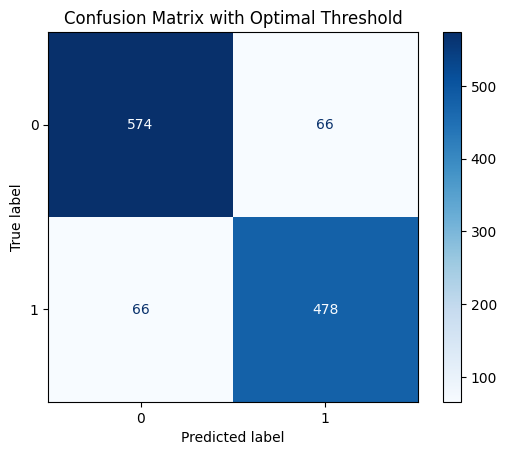

In [ ]:
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_optimal)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix with Optimal Threshold")
plt.show()

If I compare the initial confusion matrix and the second one with the optimal threshold:
*   True negatives increased from 348 to 574 which means my model is now correctly clasifies more negatives.
*   False positives decreased from 292 to 66 meaning my model is now making fewer mistakes
*   False negatives increased from 19 to 66 which means more positives are now misclassified
*   True positives decreased from 525 to 478 meaning my model is classifying fewer positives as true positives in higher threshold

So, optimal threshold improved my model's ability to avoid false positives but also lead to a higher number of missed positive cases.



